# Version 2: Own co-occurrence matrix

#### Advantages
- can simulate upskilling as in Nesta approach

#### Disadvantages
- the calculation of an average skills profile at the ISCO 3-digit level seems a bit sketchy...

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.5)

Define paths to lfs data

In [2]:
fpath_lfs = r"C:\eurostat_data"
main_data = r"Yearly Data\YearlyFiles_83_2019\_YearlyFiles"

Read geodata with NUTS regions

In [3]:
gdf = gpd.read_file(os.path.join(fpath_lfs, "felix", "NUTS_RG_03M_2021_4326_LEVL_2", "NUTS_RG_03M_2021_4326_LEVL_2.shp"))

Zoom in on Germany

In [4]:
df_de = pd.read_csv(
    os.path.join(fpath_lfs, "felix", "eu_lfs_merged_de_2019.csv")
)

## Occupation distance analysis

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [5]:
# Read occupations with their ISCO level
occ = pd.read_csv(os.path.join(fpath_lfs, "felix", "occupations_en.csv"))
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix
occ_skills_mat = pd.read_pickle(os.path.join(fpath_lfs, "felix", "adjacency_matrix_essential_optional.pkl"))
occ_skills_mat[occ_skills_mat == 2] = 0.5

# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

# Aggregate original occ-skills matrix to ISCO 3-digit level
occ_skills_mat.index = index
occ_skills_mat_isco3 = occ_skills_mat.groupby(occ_skills_mat.index.get_level_values(1)).mean()

# Calculate occupation similarity matrix at ISCO 3-digit level
occ_sims_isco3 = np.matmul(occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose())

# Find labels for isco codes
isco_groups = pd.read_csv(os.path.join(fpath_lfs, "felix", "ISCOGroups_en.csv"))

isco_groups_labels = pd.merge(
    pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(int), columns=["code"]),
    isco_groups[["code", "conceptUri", "preferredLabel"]],
    on="code",
    how="left"
)

arrays = [isco_groups_labels.conceptUri.values, isco_groups_labels.preferredLabel.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])

# to df
df_occ_sims = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)

In [6]:
similarity_matrix = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix, 0)

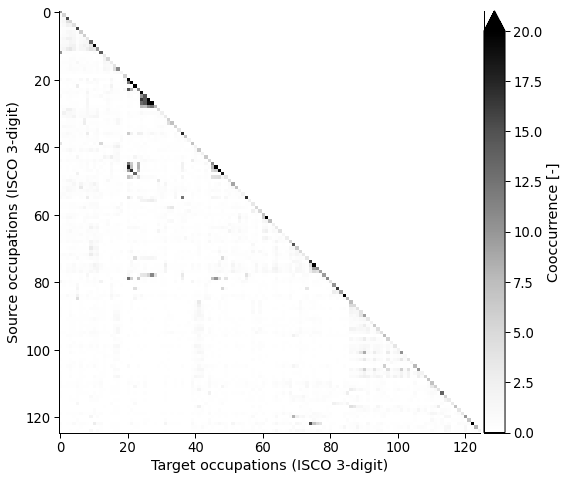

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(np.tril(df_occ_sims.values), cmap="Greys", vmax=20)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical', label="Cooccurrence [-]", extend="max")
ax.set_ylabel("Source occupations (ISCO 3-digit)")
ax.set_xlabel("Target occupations (ISCO 3-digit)")

sns.despine()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "transition_analysis_de_2019_cooccurrence_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

Implement searching for closest occupation groups

In [8]:
# source: https://github.com/nestauk/mapping-career-causeways/blob/main/mapping_career_causeways/compare_nodes_utils.py
def find_closest(i, similarity_matrix, df):
    """
    Method for reporting the closest neighbours to a node i given a similarity matrix;
    useful during exploratory data analysis.
    Parameters
    ----------
    i (int OR None):
        Determines for which node where are assessing the closest neighbours;
        if i==None, a random node is chosen.
    similarity_matrix (numpy.ndarray):
        Similarity matrix determining the closeness between each pair of nodes.
    df (pandas.DataFrame):
        Dataframe to be used for reporting the closest neighbours; must have then
        same number of rows as the similarity matrix
    Returns
    -------
    df (pandas.DataFrame):
        The same input dataframe with an added column for similarity values
        between node i and the rest of the nodes, ordered in a descending order
        of similarity.
    """
    if type(i) == type(None):
        i = np.random.randint(similarity_matrix.shape[0])

    most_similar = np.flip(np.argsort(similarity_matrix[i,:]))
    similarity = np.flip(np.sort(similarity_matrix[i,:]))

    df = df.copy().loc[most_similar]
    df['similarity'] = similarity
    return df

In [9]:
df_occs = df_occ_sims.index.to_frame().reset_index(drop=True)

In [10]:
threatened_occs = {
    'Mining, manufacturing and construction supervisors': '312',
    'Mining and mineral processing plant operators': '811',
    'Manufacturing, mining, construction, and distribution managers': '132',
    'Mining and construction labourers': '931'
}

Manually check some transitions

In [11]:
occ = df_occs.loc[df_occs.occ == 'Mining and construction labourers']
print(occ.occ)

transitions = find_closest(
    i=occ.index.values[0],
    similarity_matrix=similarity_matrix,
    df=df_occs
)

transitions.head(5)

117    Mining and construction labourers
Name: occ, dtype: object


,occ_uri,occ,similarity
86,http://data.europa.eu/esco/isco/C711,Building frame and related trades workers,4.268519
87,http://data.europa.eu/esco/isco/C712,Building finishers and related trades workers,3.341111
112,http://data.europa.eu/esco/isco/C834,Mobile plant operators,3.054094
41,http://data.europa.eu/esco/isco/C312,"Mining, manufacturing and construction supervi...",2.331967
94,http://data.europa.eu/esco/isco/C741,Electrical equipment installers and repairers,1.407005


#### Aggregate to ISCO 3-digit level

In [12]:
agg_dict = {"COEFF": np.sum, "AGE": np.mean, "INCDECIL": np.median, "is_green": np.mean, "is_brown": np.mean, "is_neutral": np.mean, "annual_earnings_2016": np.mean}
isco3d_avg_de = df_de.groupby("ISCO3D_label").aggregate(agg_dict)

# define the GBN category of an ISCO 3D group as the one with the highest fraction (of ESCO occupations)
isco3d_avg_de["category"] = isco3d_avg_de[['is_brown', 'is_green', 'is_neutral']].idxmax(axis=1)

# merge to df
df_occs_metadata = pd.merge(
    df_occs,
    isco3d_avg_de.reset_index(),
    left_on="occ",
    right_on="ISCO3D_label",
    how="left"
).drop(["ISCO3D_label", "is_green", "is_brown", "is_neutral"], axis=1)

Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

Viable/highly viable transitions
- Mining and mineral processing plant operators: 0
- Manufacturing, mining, construction, and distr: 2
- Mining, manufacturing and construction supervi: 1
- Mining and construction labourers: 8

In [13]:
q_viable = np.percentile(df_occ_sims.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims.values.flatten(), q=99)

print(q_viable, q_highly_viable)

1.4301400333412675 5.477203125000002


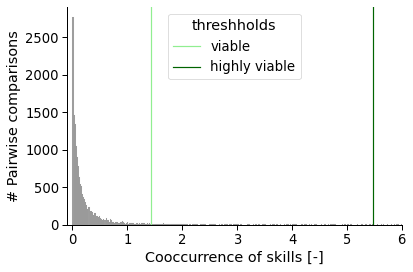

In [14]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey")
ax.set_xlim(-0.1, 6)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "transition_analysis_de_2019_threshholds.png"),
    dpi=300,
    bbox_inches="tight"
)

Occupation similarity matrix classified viable/highly viable

In [15]:
similarity_matrix_classified = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix_classified, 0)

similarity_matrix_classified[similarity_matrix_classified < q_viable] = 0
similarity_matrix_classified[(similarity_matrix_classified >= q_viable) & (similarity_matrix_classified < q_highly_viable)] = 1
similarity_matrix_classified[similarity_matrix_classified >= q_highly_viable] = 2

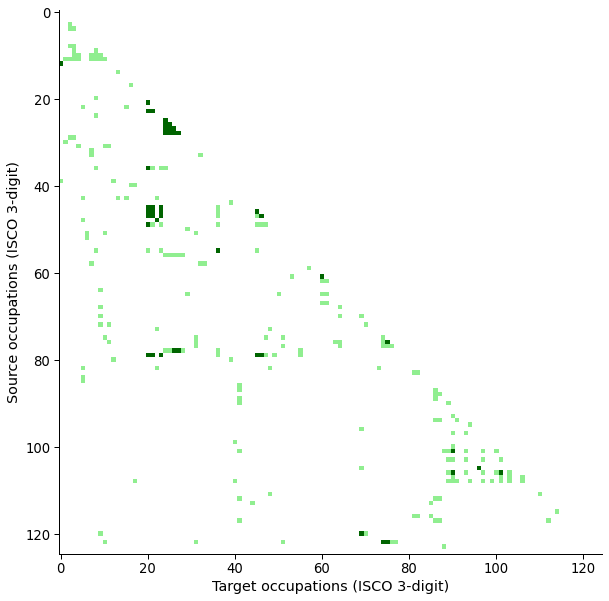

In [16]:
from matplotlib import colors

fig, ax = plt.subplots(figsize=(10, 10))

# make a color map of fixed colors
cmap = colors.ListedColormap(['white', 'lightgreen', 'darkgreen'])
bounds=[0,1,2,3]
norm = colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(np.tril(similarity_matrix_classified), cmap=cmap, norm=norm)

ax.set_ylabel("Source occupations (ISCO 3-digit)")
ax.set_xlabel("Target occupations (ISCO 3-digit)")

sns.despine()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "transition_analysis_de_2019_cooccurrence_matrix_classified.png"),
    dpi=300,
    bbox_inches="tight"
)

Zoom in on coal-related jobs

In [17]:
df_de_merged_mining = df_de.loc[df_de.mining == True]

### Analyse number of viable transitions

In [18]:
cmap_earnings = plt.get_cmap("coolwarm_r", 16)
cmap_transitions = plt.get_cmap("Blues", 14)

# upper limits for colorbars
vmax_transitions = 14  # n viable transitions
vmax_wages = 40  # million euro

initialise dict to store estimates of total wage changes

In [19]:
earnings_losses = {}

#### Scenario 1: Workers follow closest viable transition regardless of earnings losses (Skills continuity scenario)

In [20]:
transition_number_data = []

for i, search_obs in df_de_merged_mining.iterrows():

    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    target_occs = find_closest(
        i=idx,
        similarity_matrix=similarity_matrix,
        df=df_occs_metadata
    )

    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target = target_occs_filtered.head(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)

# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

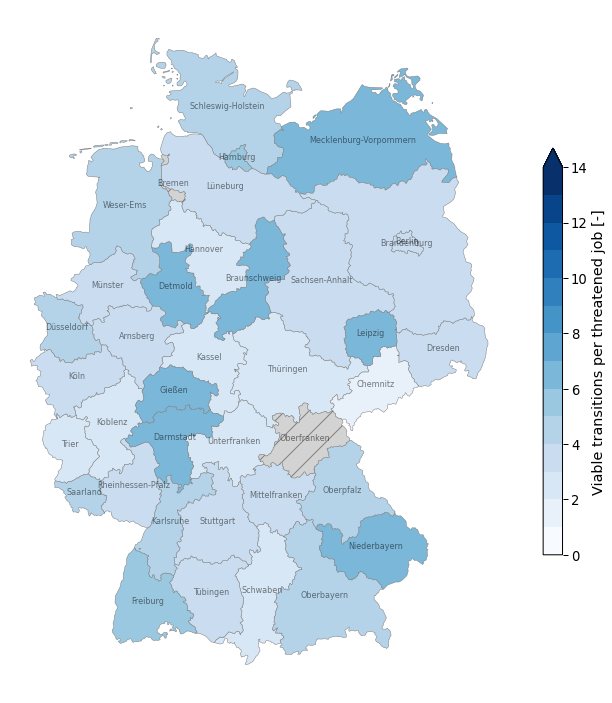

In [21]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Viable transitions per threatened job [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "viable_transitions.png"), dpi=300, bbox_inches="tight")

#### Not sure if this makes sense...

risk = 1 / n_viable_transitions * n_at_risk_jobs

if n_viable_transitions = 0, ratio is set to 1

(5.4133400499999995, 15.49109895, 46.88094145, 55.44273755)

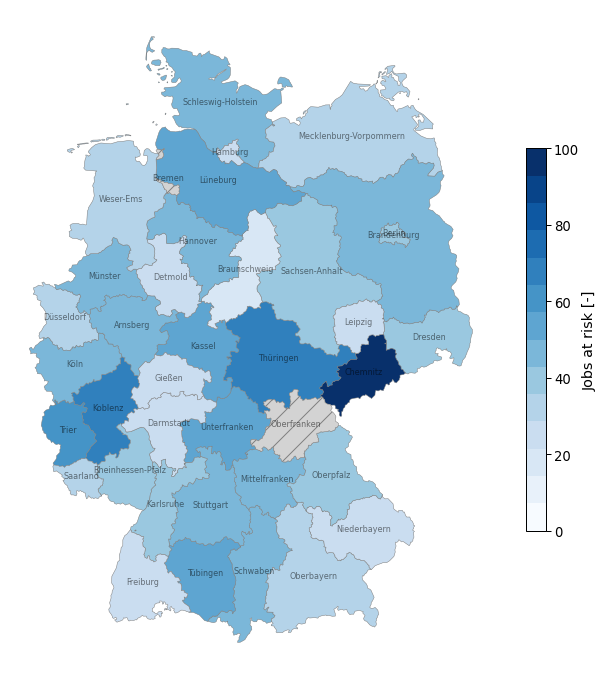

In [22]:
gdf_transition_numbers_by_nuts["risk_indicator"] = (1 / gdf_transition_numbers_by_nuts.n_viable_transitions).replace([np.inf, -np.inf], 1) * gdf_transition_numbers_by_nuts.COEFF

cmap = plt.get_cmap("Blues", 8)
ax = gdf_transition_numbers_by_nuts.plot(column="risk_indicator", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=100, legend_kwds={"label": "Jobs at risk [-]", "fraction": 0.03}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
plt.tight_layout()
ax.axis('off')

(5.4133400499999995, 15.49109895, 46.88094145, 55.44273755)

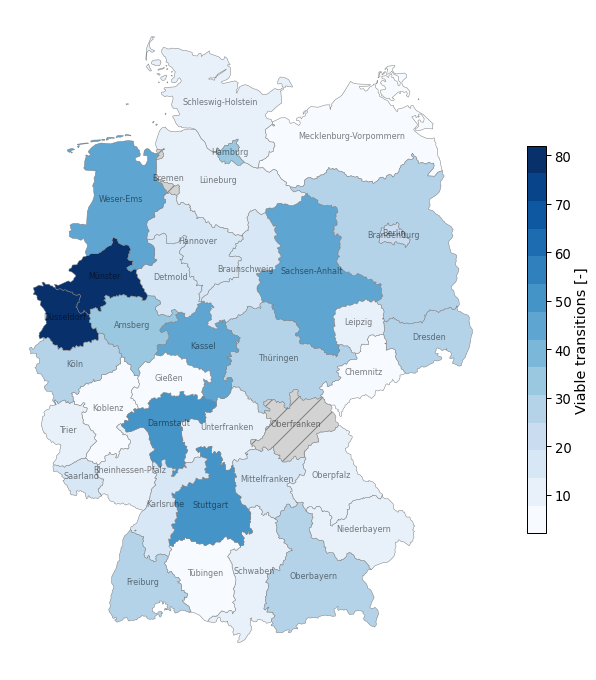

In [23]:
cmap = plt.get_cmap("Blues", 6)
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions", figsize=(10, 10), legend=True, cmap=cmap_transitions, legend_kwds={"label": "Viable transitions [-]", "fraction": 0.03}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
plt.tight_layout()
ax.axis('off')

Assumptions:
- every worker in the source occupation switches to the same target occupation

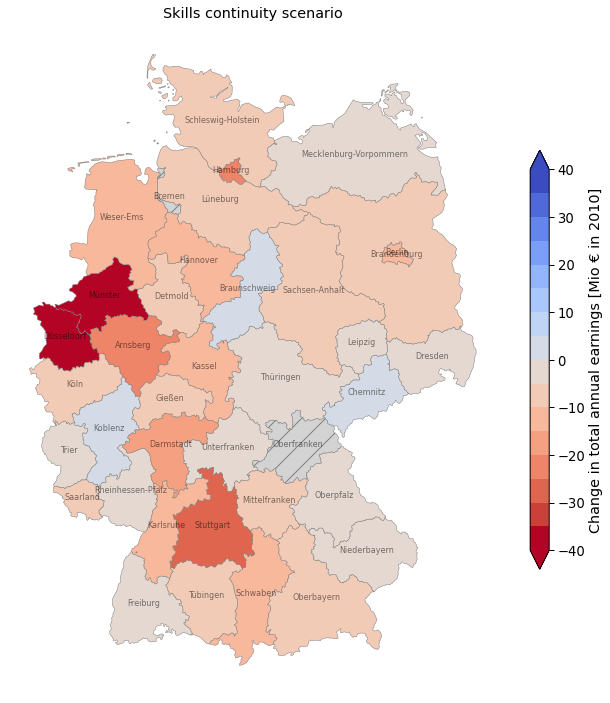

In [24]:
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [Mio € in 2010]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("Skills continuity scenario")
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_skills_continuity.png"), dpi=300, bbox_inches="tight")

Comparison of costs with Kohleaustiegsbudget

In [25]:
earnings_losses["skills_continuity"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

8.240393977099206e-09


-329.61575908396827

#### Scenario 2: Workers follow viable transition that minimises earnings losses (wage continuity scenario)

In [26]:
transition_number_data = []

for i, search_obs in df_de_merged_mining.iterrows():
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]
    
    target_occs = find_closest(
        i=idx,
        similarity_matrix=similarity_matrix,
        df=df_occs_metadata
    )
    
    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    
    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)
    
# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

# save
gdf_transition_numbers_by_nuts.to_csv(os.path.join(fpath_lfs, "felix", "rq5_results_before_reskilling.csv"))

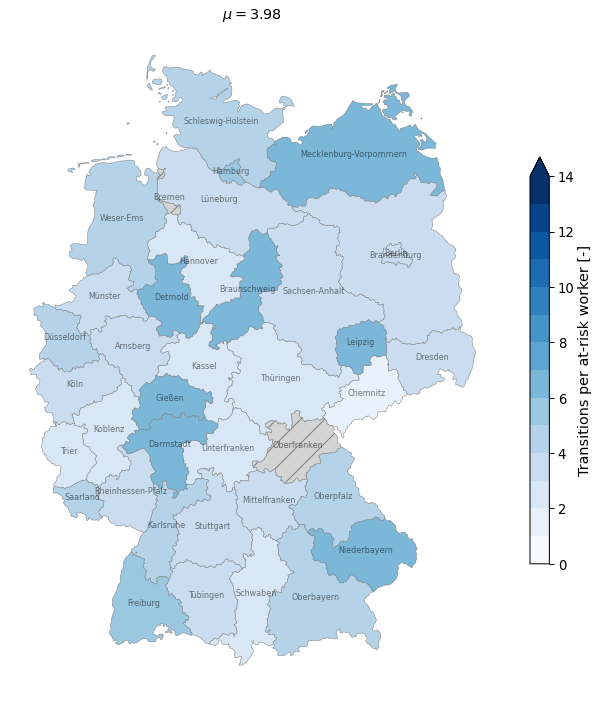

In [27]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Transitions per at-risk worker [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)


ax.set_title("$\mu = {:.2f}$".format(gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()))
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "viable_transitions.png"), dpi=300, bbox_inches="tight")

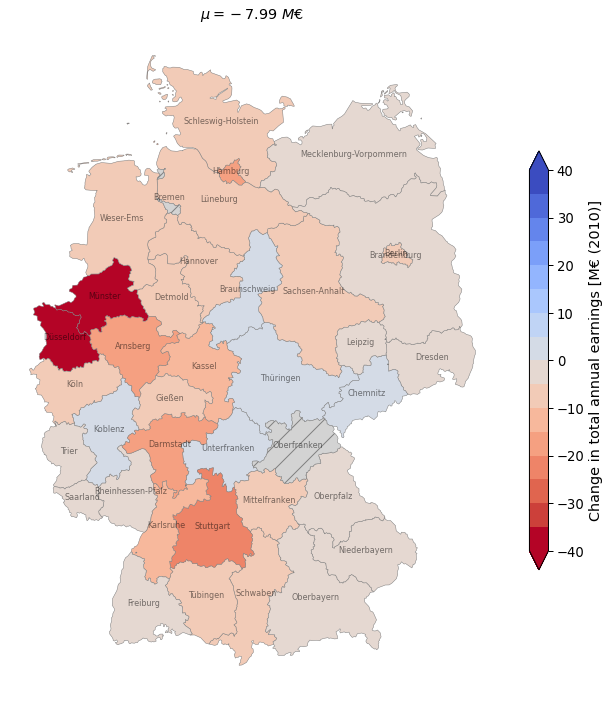

In [28]:
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [M€ (2010)]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("$\mu = {:.2f}~M€$".format(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.mean()))
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity.png"), dpi=300, bbox_inches="tight")

Comparison of costs with Kohleaustiegsbudget

In [29]:
earnings_losses["wage_continuity"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

7.190322526698131e-09


-287.61290106792524

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [30]:
threatened_occs = {
    'Mining, manufacturing and construction supervisors': '312',
    'Mining and mineral processing plant operators': '811',
    'Manufacturing, mining, construction, and distribution managers': '132',
    'Mining and construction labourers': '931'
}

In [31]:
df_top_skills_per_occ = pd.read_csv(os.path.join(fpath_lfs, "felix", "upskilling_best_5_skills_per_occupation.csv"), index_col=0)

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [32]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]
    
    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)
    
df_optimal_upskilling_per_occ = pd.concat(optimal_upskilling_per_occ, axis=0).reset_index(drop=True)

# get skill id
coreness = pd.read_csv(os.path.join(fpath_lfs, "felix", "skills_coreness_measure.csv"), index_col=0)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["id", "preferred_label"]].rename(columns={"preferred_label": "Skill", "id": "id_skill"}),
    on="Skill"
)

df_optimal_upskilling_per_occ["id_occ"] = [threatened_occs[occ_label] for occ_label in df_optimal_upskilling_per_occ.Occupation.values]

df_optimal_upskilling_per_occ.to_csv(os.path.join(fpath_lfs, "felix", "upskilling_selected_skill_per_occupation.csv"))
df_optimal_upskilling_per_occ

,Occupation,Skill,Coreness,Viable transitions,id_skill,id_occ
0,"Manufacturing, mining, construction, and distr...",company policies,0.35,5,13004,132
1,Mining and construction labourers,troubleshoot,0.55,3,2756,931
2,Mining and mineral processing plant operators,quality standards,0.71,3,7508,811
3,"Mining, manufacturing and construction supervi...",quality standards,0.71,6,7508,312


In [33]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [34]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

In [35]:
occ = df_optimal_upskilling_per_occ.iloc[0]

# find index of occ
idx_occ = occ_codes.index(occ.id_occ)
idx_new_skill = occ.id_skill

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

#### 1) Skills continuity scenario with upskilling

In [36]:
transition_number_data = []

for i, search_obs in df_de_merged_mining.iterrows():

    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]
    
    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[df_optimal_upskilling_per_occ.Occupation == search_label]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)
    
    # find closest transitions
    target_occs = find_closest(
        i=idx,
        similarity_matrix=occ_sims_isco3_upskilling,
        df=df_occs_metadata
    )
    
    # filter
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target = target_occs_filtered.head(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)

# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

(5.4133400499999995, 15.49109895, 46.88094145, 55.44273755)

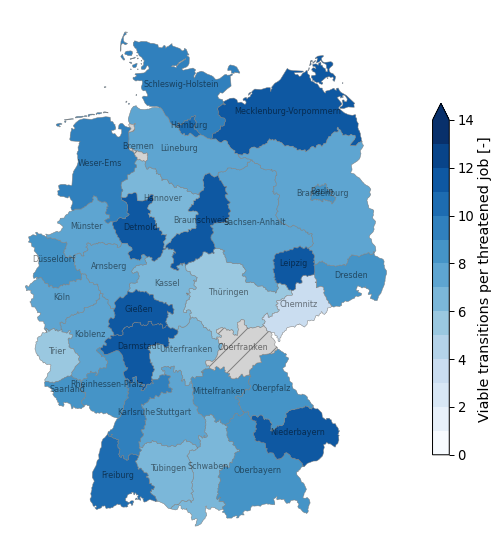

In [37]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Viable transitions per threatened job [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

#ax.set_title("Viable transitions (upskilling)")
ax.axis('off')

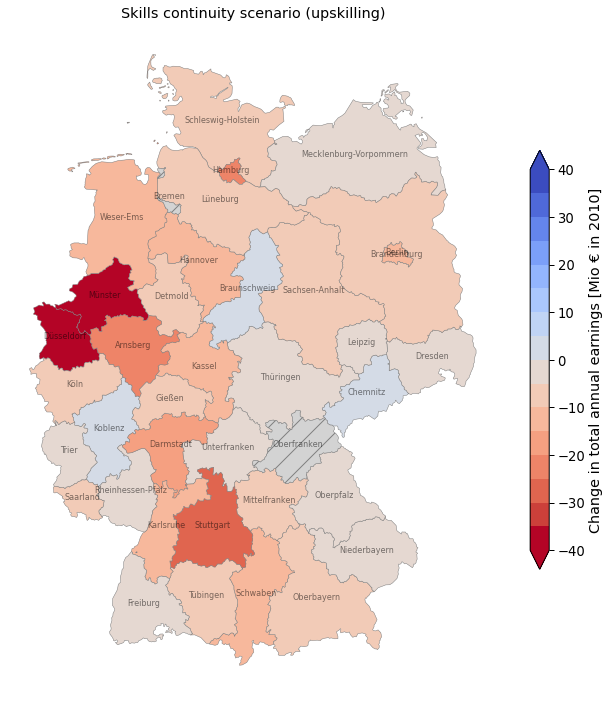

In [38]:
cmap = plt.get_cmap("RdYlGn")
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [Mio € in 2010]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("Skills continuity scenario (upskilling)")
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_skills_continuity_upskilling.png"), dpi=300, bbox_inches="tight")

In [39]:
earnings_losses["skills_continuity_upskilling"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

8.240393977099206e-09


-329.61575908396827

#### 2) Wage continuity scenario with upskilling

In [40]:
transition_number_data = []

for i, search_obs in df_de_merged_mining.iterrows():
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]
    
    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[df_optimal_upskilling_per_occ.Occupation == search_label]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)
    
    # find closest transitions
    target_occs = find_closest(
        i=idx,
        similarity_matrix=occ_sims_isco3_upskilling,
        df=df_occs_metadata
    )
    
    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    
    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)
    
# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

# save
gdf_transition_numbers_by_nuts.to_csv(os.path.join(fpath_lfs, "felix", "rq5_results_after_reskilling.csv"))

Transition numbers for "Wage continuity scenario (upskilling)" should be the same as for "Skills continuity scenario (upskilling)"

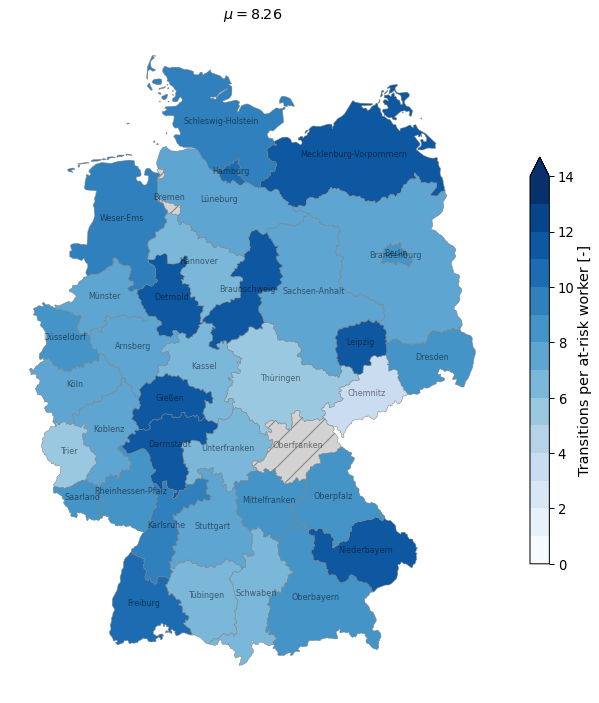

In [41]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Transitions per at-risk worker [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)


ax.set_title("$\mu = {:.2f}$".format(gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()))
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "viable_transitions_upskilling.png"), dpi=300, bbox_inches="tight")

8.24142003847626

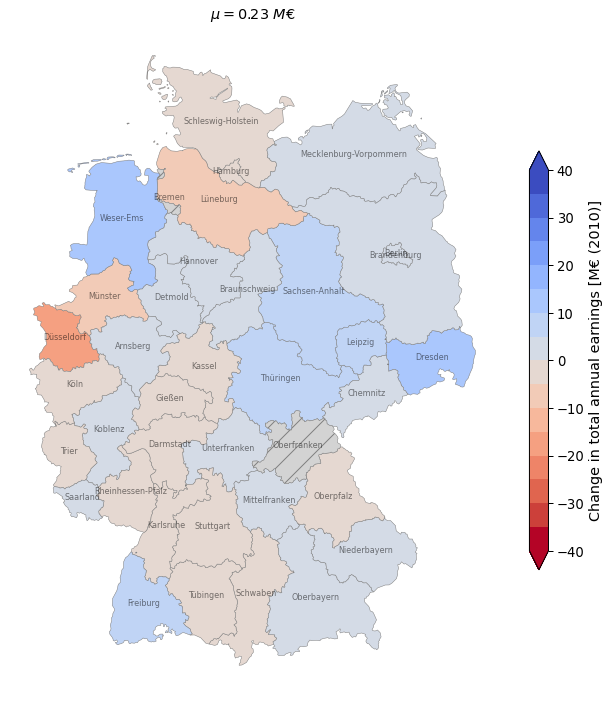

In [42]:
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [M€ (2010)]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("$\mu = {:.2f}~M€$".format(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.mean()))
ax.axis('off')

plt.tight_layout()

plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity_upskilling.png"), dpi=300, bbox_inches="tight")

gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

In [43]:
earnings_losses["wage_continuity_upskilling"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

2.060355009619065e-10


8.24142003847626

#### Comparison of earnings losses across scenarios

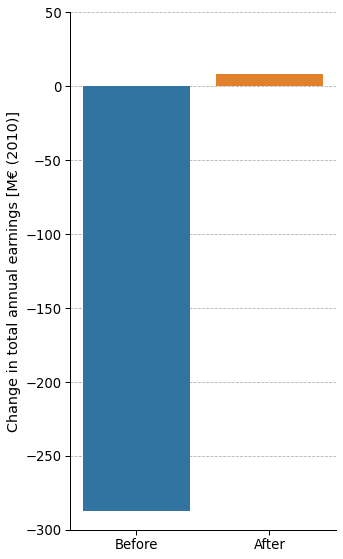

In [44]:
df_earnings_losses = pd.DataFrame.from_dict(earnings_losses, orient="index", columns=["annual_earnings_delta"])
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.iloc[[1,3], :].reset_index()

fig, ax = plt.subplots(figsize=(5,8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2010)]")
ax.set_ylim(-300, 50)

plt.xticks(np.arange(2), ['Before', 'After'])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()

plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity_comparison.png"), dpi=300, bbox_inches="tight")

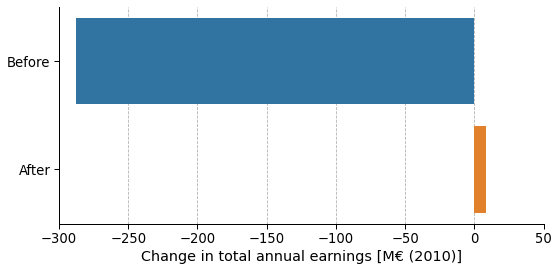

In [45]:
df_earnings_losses = pd.DataFrame.from_dict(earnings_losses, orient="index", columns=["annual_earnings_delta"])
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.iloc[[1,3], :].reset_index()

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta",
    ax=ax,
    zorder=2,
    orient="h"
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2010)]")
ax.set_xlim(-300, 50.5)

plt.yticks(np.arange(2), ['Before', 'After'])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()

plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity_comparison_h.png"), dpi=300, bbox_inches="tight")

Pension in Germany with 67 years

In [46]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_15yrs"] = wage_scenario.annual_earnings_delta * age_delta

wage_scenario.to_csv(os.path.join(fpath_lfs, "felix", "total_earnings_changes_wage_continuity_de_2019.csv"))
wage_scenario

,scenario,annual_earnings_delta,earnings_delta_15yrs
0,wage_continuity,-287.612901,-4314.193516
1,wage_continuity_upskilling,8.241420,123.621301
